In [ ]:
# ============================================================
# OIBSIP - DATA ANALYTICS
# LEVEL 2 - TASK 3: FRAUD DETECTION
# ============================================================

!pip -q install imbalanced-learn

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

from imblearn.over_sampling import SMOTE

# Download dataset
url = "https://zenodo.org/records/7395559/files/creditcard.csv?download=1"

df = pd.read_csv(url)

print("=" * 70)
print("FRAUD DETECTION DATASET LOADED SUCCESSFULLY! ✅")
print("=" * 70)

print("Dataset Shape:", df.shape)

display(df.head())

FRAUD DETECTION DATASET LOADED SUCCESSFULLY! ✅
Dataset Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



1. DATASET INSPECTION
Rows: 284807
Columns: 31

Data Types:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

Missing Values:
0

Duplicate Rows:
1081

2. FRAUD CLASS DISTRIBUTION
Non-Fraud Transactions: 284315
Fraud Transactions: 492
Fraud Percentage: 0.1727%


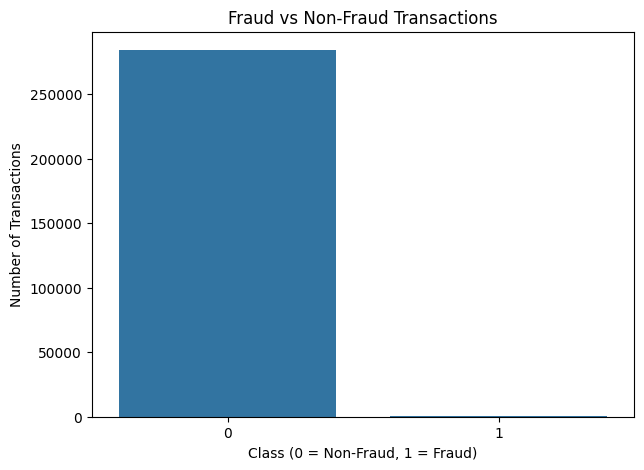

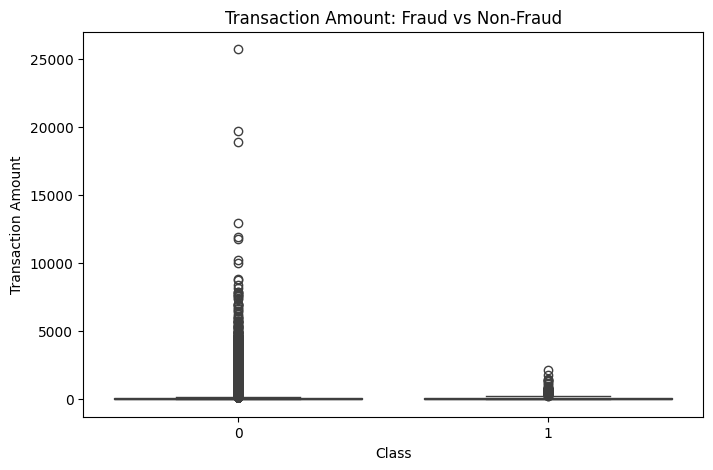

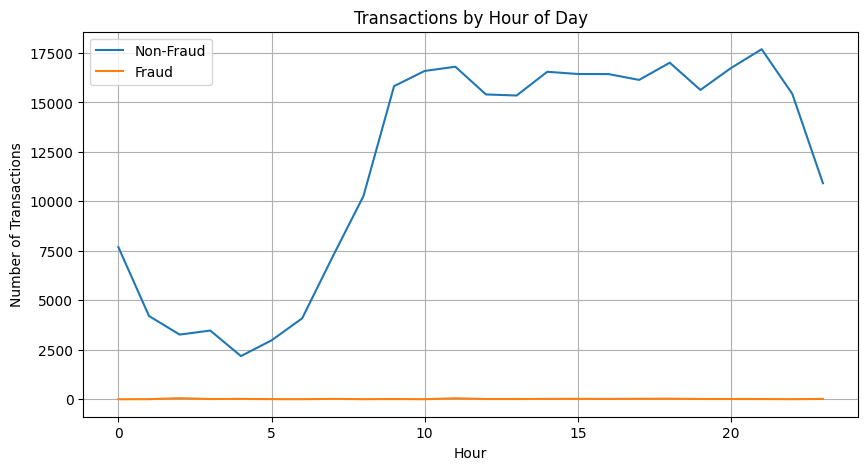


CLASS IMBALANCE EXPLANATION

The fraud dataset is highly imbalanced because fraudulent
transactions represent only a very small percentage of all
transactions.

Accuracy alone can therefore be misleading. A model could
predict almost every transaction as non-fraud and still obtain
very high accuracy while failing to detect actual fraud.

Therefore, Precision, Recall, F1-Score and AUC-ROC are used
to evaluate the fraud detection models.


Feature Shape: (284807, 30)
Target Shape: (284807,)

TRAIN / TEST SPLIT
Training samples: 227845
Testing samples: 56962

Fraud cases in training: 394
Fraud cases in testing: 98

Feature scaling completed.

APPLYING SMOTE
Before SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64

TRAINING LOGISTIC REGRESSION
Logistic Regression training completed.

TRAINING RANDOM FOREST
Random Forest training completed.

------------------------------------------------------------
LOGIST

,Model,Precision,Recall,F1-Score,AUC-ROC
0,Logistic Regression,0.0578,0.9184,0.1088,0.9708
1,Random Forest,0.8710,0.8265,0.8482,0.9684


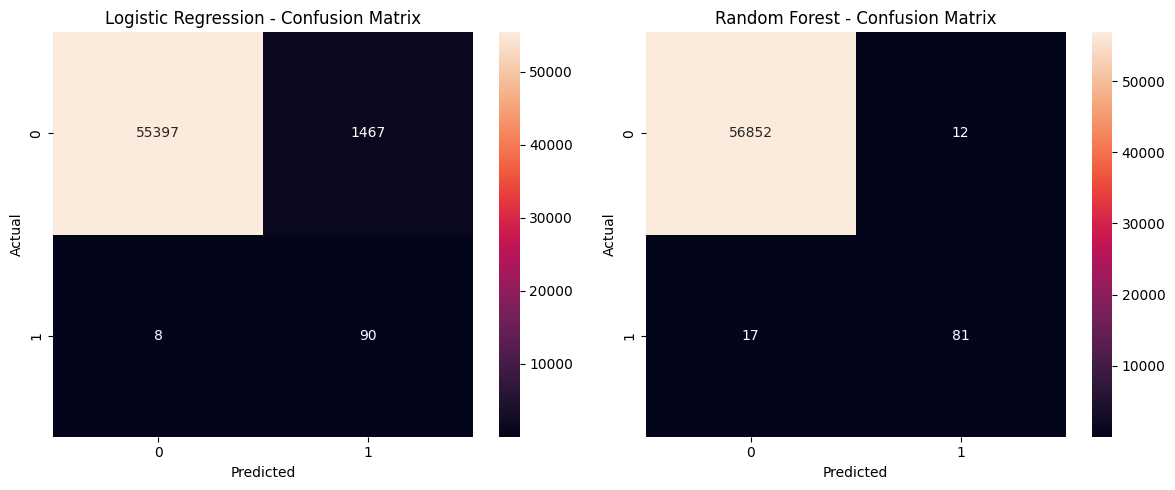

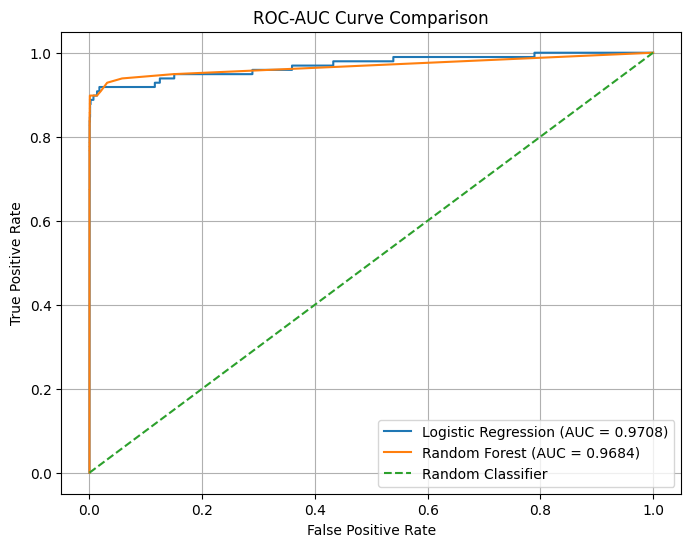


TOP 15 IMPORTANT FEATURES


,Feature,Importance
14,V14,0.191127
10,V10,0.111454
4,V4,0.111395
12,V12,0.095690
17,V17,0.082761
3,V3,0.063935
11,V11,0.049290
16,V16,0.045124
2,V2,0.038541
9,V9,0.026552


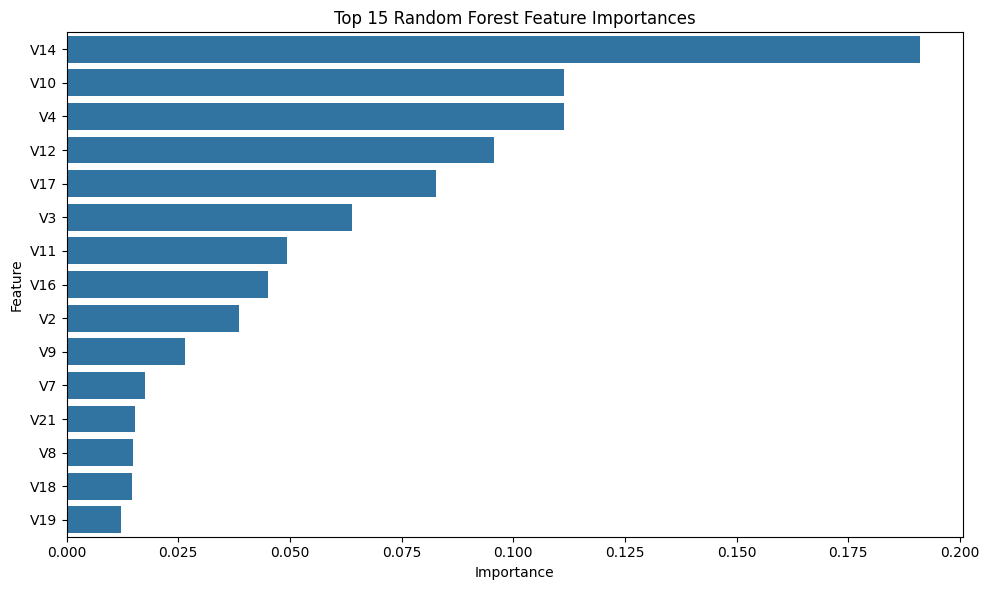


FRAUD DETECTION METRIC DISCUSSION

For fraud detection, Recall is especially important because
missing a fraudulent transaction can cause financial loss.

However, very high Recall can sometimes increase false positives.
Therefore, Precision and Recall should be considered together.

F1-Score provides a balance between Precision and Recall,
while AUC-ROC measures the model's ability to distinguish
between fraudulent and legitimate transactions.


SCALABILITY DISCUSSION

For a system processing one million transactions per hour,
the model would need efficient feature processing,
distributed computing, batch or streaming pipelines,
real-time monitoring, and scalable infrastructure.

A production system could use technologies such as Kafka,
Spark, cloud services, model serving APIs, and continuous
model monitoring.

The model should also be periodically retrained because
fraud patterns can change over time.


FINAL CONCLUSION

1. The dataset was highly imbalanced, with fraudulent
   tran

In [ ]:
# ============================================================
# FRAUD DETECTION - COMPLETE ANALYSIS & MODEL BUILDING
# ============================================================

print("\n" + "=" * 70)
print("1. DATASET INSPECTION")
print("=" * 70)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())


# ============================================================
# 2. CLASS IMBALANCE ANALYSIS
# ============================================================

print("\n" + "=" * 70)
print("2. FRAUD CLASS DISTRIBUTION")
print("=" * 70)

class_counts = df["Class"].value_counts()

print("Non-Fraud Transactions:", class_counts.get(0, 0))
print("Fraud Transactions:", class_counts.get(1, 0))

fraud_percentage = (df["Class"].mean()) * 100

print(f"Fraud Percentage: {fraud_percentage:.4f}%")

plt.figure(figsize=(7, 5))
sns.countplot(x="Class", data=df)
plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Class (0 = Non-Fraud, 1 = Fraud)")
plt.ylabel("Number of Transactions")
plt.show()


# ============================================================
# 3. TRANSACTION AMOUNT ANALYSIS
# ============================================================

plt.figure(figsize=(8, 5))
sns.boxplot(x="Class", y="Amount", data=df)
plt.title("Transaction Amount: Fraud vs Non-Fraud")
plt.xlabel("Class")
plt.ylabel("Transaction Amount")
plt.show()


# ============================================================
# 4. TIME-OF-DAY ANALYSIS
# ============================================================

df["Hour"] = ((df["Time"] // 3600) % 24).astype(int)

hourly_transactions = df.groupby(["Hour", "Class"]).size().unstack(fill_value=0)

plt.figure(figsize=(10, 5))

if 0 in hourly_transactions.columns:
    plt.plot(
        hourly_transactions.index,
        hourly_transactions[0],
        label="Non-Fraud"
    )

if 1 in hourly_transactions.columns:
    plt.plot(
        hourly_transactions.index,
        hourly_transactions[1],
        label="Fraud"
    )

plt.title("Transactions by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Transactions")
plt.legend()
plt.grid(True)
plt.show()


# ============================================================
# 5. WHY ACCURACY ALONE IS NOT ENOUGH
# ============================================================

print("\n" + "=" * 70)
print("CLASS IMBALANCE EXPLANATION")
print("=" * 70)

print("""
The fraud dataset is highly imbalanced because fraudulent
transactions represent only a very small percentage of all
transactions.

Accuracy alone can therefore be misleading. A model could
predict almost every transaction as non-fraud and still obtain
very high accuracy while failing to detect actual fraud.

Therefore, Precision, Recall, F1-Score and AUC-ROC are used
to evaluate the fraud detection models.
""")


# ============================================================
# 6. PREPARE FEATURES AND TARGET
# ============================================================

X = df.drop("Class", axis=1)
y = df["Class"]

# Remove Hour because it was created only for EDA
if "Hour" in X.columns:
    X = X.drop("Hour", axis=1)

print("\nFeature Shape:", X.shape)
print("Target Shape:", y.shape)


# ============================================================
# 7. TRAIN / TEST SPLIT WITH STRATIFICATION
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\n" + "=" * 70)
print("TRAIN / TEST SPLIT")
print("=" * 70)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nFraud cases in training:", y_train.sum())
print("Fraud cases in testing:", y_test.sum())


# ============================================================
# 8. FEATURE SCALING
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeature scaling completed.")


# ============================================================
# 9. HANDLE CLASS IMBALANCE USING SMOTE
# ============================================================

print("\n" + "=" * 70)
print("APPLYING SMOTE")
print("=" * 70)

print("Before SMOTE:")
print(y_train.value_counts())

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())


# ============================================================
# 10. LOGISTIC REGRESSION
# ============================================================

print("\n" + "=" * 70)
print("TRAINING LOGISTIC REGRESSION")
print("=" * 70)

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train_smote,
    y_train_smote
)

logistic_predictions = logistic_model.predict(X_test_scaled)
logistic_probabilities = logistic_model.predict_proba(
    X_test_scaled
)[:, 1]

print("Logistic Regression training completed.")


# ============================================================
# 11. RANDOM FOREST
# ============================================================

print("\n" + "=" * 70)
print("TRAINING RANDOM FOREST")
print("=" * 70)

random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

random_forest_model.fit(
    X_train_smote,
    y_train_smote
)

rf_predictions = random_forest_model.predict(X_test_scaled)

rf_probabilities = random_forest_model.predict_proba(
    X_test_scaled
)[:, 1]

print("Random Forest training completed.")


# ============================================================
# 12. MODEL EVALUATION FUNCTION
# ============================================================

def evaluate_model(name, y_true, predictions, probabilities):

    precision = precision_score(
        y_true,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        predictions,
        zero_division=0
    )

    auc = roc_auc_score(
        y_true,
        probabilities
    )

    print("\n" + "-" * 60)
    print(name)
    print("-" * 60)

    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1-Score  : {f1:.4f}")
    print(f"AUC-ROC   : {auc:.4f}")

    print("\nClassification Report:")
    print(
        classification_report(
            y_true,
            predictions,
            zero_division=0
        )
    )

    return precision, recall, f1, auc


# ============================================================
# 13. EVALUATE BOTH MODELS
# ============================================================

logistic_results = evaluate_model(
    "LOGISTIC REGRESSION",
    y_test,
    logistic_predictions,
    logistic_probabilities
)

rf_results = evaluate_model(
    "RANDOM FOREST",
    y_test,
    rf_predictions,
    rf_probabilities
)


# ============================================================
# 14. MODEL COMPARISON TABLE
# ============================================================

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Precision": [
        logistic_results[0],
        rf_results[0]
    ],
    "Recall": [
        logistic_results[1],
        rf_results[1]
    ],
    "F1-Score": [
        logistic_results[2],
        rf_results[2]
    ],
    "AUC-ROC": [
        logistic_results[3],
        rf_results[3]
    ]
})

print("\n" + "=" * 70)
print("MODEL COMPARISON")
print("=" * 70)

display(comparison.round(4))


# ============================================================
# 15. CONFUSION MATRICES
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_logistic = confusion_matrix(
    y_test,
    logistic_predictions
)

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    ax=axes[0]
)

axes[0].set_title("Logistic Regression - Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")


cm_rf = confusion_matrix(
    y_test,
    rf_predictions
)

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    ax=axes[1]
)

axes[1].set_title("Random Forest - Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()


# ============================================================
# 16. ROC CURVE
# ============================================================

fpr_logistic, tpr_logistic, _ = roc_curve(
    y_test,
    logistic_probabilities
)

fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    rf_probabilities
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_logistic,
    tpr_logistic,
    label=f"Logistic Regression (AUC = {logistic_results[3]:.4f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {rf_results[3]:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("ROC-AUC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()


# ============================================================
# 17. RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\n" + "=" * 70)
print("TOP 15 IMPORTANT FEATURES")
print("=" * 70)

display(feature_importance.head(15))

plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


# ============================================================
# 18. WHICH METRIC MATTERS MOST?
# ============================================================

print("\n" + "=" * 70)
print("FRAUD DETECTION METRIC DISCUSSION")
print("=" * 70)

print("""
For fraud detection, Recall is especially important because
missing a fraudulent transaction can cause financial loss.

However, very high Recall can sometimes increase false positives.
Therefore, Precision and Recall should be considered together.

F1-Score provides a balance between Precision and Recall,
while AUC-ROC measures the model's ability to distinguish
between fraudulent and legitimate transactions.
""")


# ============================================================
# 19. SCALABILITY DISCUSSION
# ============================================================

print("\n" + "=" * 70)
print("SCALABILITY DISCUSSION")
print("=" * 70)

print("""
For a system processing one million transactions per hour,
the model would need efficient feature processing,
distributed computing, batch or streaming pipelines,
real-time monitoring, and scalable infrastructure.

A production system could use technologies such as Kafka,
Spark, cloud services, model serving APIs, and continuous
model monitoring.

The model should also be periodically retrained because
fraud patterns can change over time.
""")


# ============================================================
# 20. FINAL CONCLUSION
# ============================================================

best_model = (
    "Random Forest"
    if rf_results[2] >= logistic_results[2]
    else "Logistic Regression"
)

print("\n" + "=" * 70)
print("FINAL CONCLUSION")
print("=" * 70)

print(f"""
1. The dataset was highly imbalanced, with fraudulent
   transactions representing only a small percentage.

2. SMOTE was used on the training data to handle class imbalance.

3. Logistic Regression and Random Forest models were trained.

4. Precision, Recall, F1-Score and AUC-ROC were used instead
   of relying only on accuracy.

5. Based on the F1-Score comparison in this experiment,
   {best_model} performed better overall.

6. Recall is particularly important because failing to detect
   fraudulent transactions can result in financial losses.

7. For production deployment, scalability, monitoring,
   retraining and changing fraud patterns must be considered.

FRAUD DETECTION TASK COMPLETED SUCCESSFULLY! ✅
""")